# NJ County Model (2022)
I keep this to show the limitation: only 9 counties have chargers in 2022, so the model fails (negative R²). I cap chargers to 2022 to match ACS 2022. Then I show visuals and bad metrics to justify pivoting to state level.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

base = Path('..')
chargers = pd.read_csv(base/'data/processed/chargers_nj_2022_by_county.csv')
acs = pd.read_csv(base/'data/processed/acs_nj_counties.csv')
merged = acs.copy()
merged.rename(columns={'name':'county_full'}, inplace=True)
merged['county'] = merged['county_full'].str.replace(' County, New Jersey','', regex=False)
merged = merged.merge(chargers, on='county', how='left')
merged[['stations','level1_ports','level2_ports','dcfc_ports']] = merged[['stations','level1_ports','level2_ports','dcfc_ports']].fillna(0)
merged['chargers_per_100k'] = merged['stations'] / (merged['population']/100000)
print('Counties', len(merged), 'with chargers>0', (merged.stations>0).sum())


Counties 21 with chargers>0 9


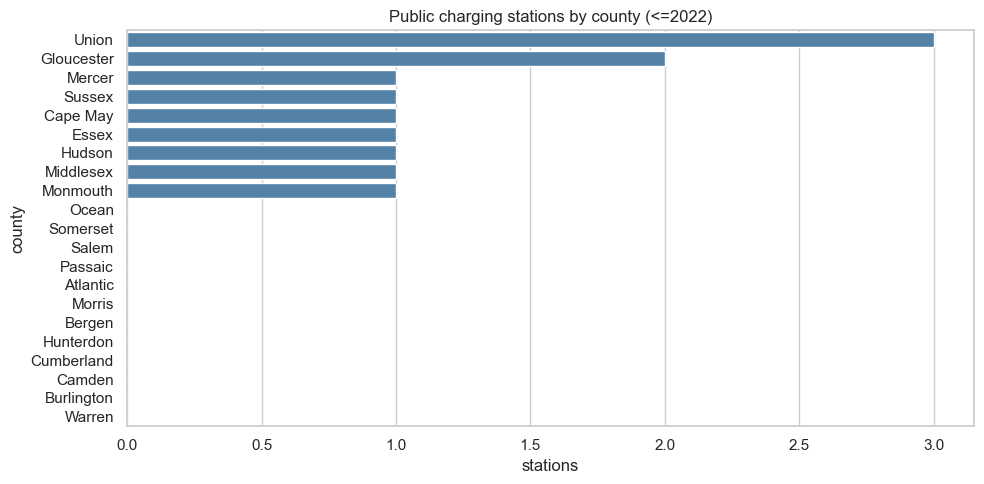

In [2]:
sns.set(style='whitegrid')
plt.figure(figsize=(10,5))
sns.barplot(data=merged.sort_values('stations', ascending=False), x='stations', y='county', color='steelblue')
plt.title('Public charging stations by county (<=2022)')
plt.tight_layout()
plt.show()

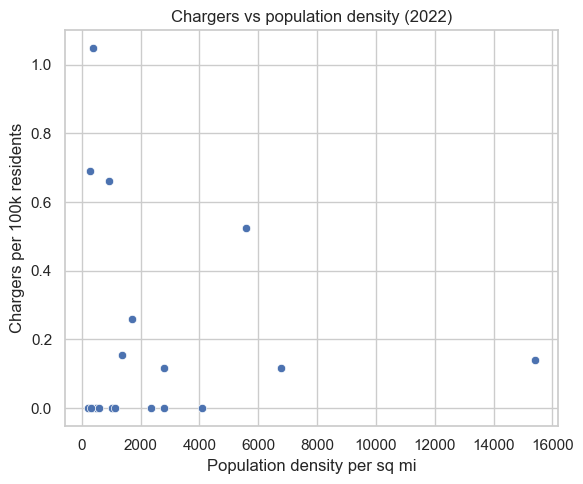

In [3]:
plt.figure(figsize=(6,5))
sns.scatterplot(data=merged, x='pop_density_per_sqmi', y='chargers_per_100k')
plt.xlabel('Population density per sq mi')
plt.ylabel('Chargers per 100k residents')
plt.title('Chargers vs population density (2022)')
plt.tight_layout()
plt.show()

In [4]:
feature_cols = ['population','median_household_income','renter_occupied_pct','mean_travel_time_to_work_minutes','pop_density_per_sqmi','chargers_per_100k']
print(merged[feature_cols].corr())

                                  population  median_household_income  \
population                          1.000000                 0.995988   
median_household_income             0.995988                 1.000000   
renter_occupied_pct                 0.901627                 0.895027   
mean_travel_time_to_work_minutes    0.548088                 0.575360   
pop_density_per_sqmi                0.574743                 0.611144   
chargers_per_100k                  -0.267910                -0.265685   

                                  renter_occupied_pct  \
population                                   0.901627   
median_household_income                      0.895027   
renter_occupied_pct                          1.000000   
mean_travel_time_to_work_minutes             0.175806   
pop_density_per_sqmi                         0.229887   
chargers_per_100k                           -0.270518   

                                  mean_travel_time_to_work_minutes  \
population        

In [5]:
features = ['population','median_household_income','renter_occupied_pct','mean_travel_time_to_work_minutes','pop_density_per_sqmi']
X = merged[features]
y = merged['chargers_per_100k']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lin = LinearRegression().fit(X_train, y_train)
pred_lin = lin.predict(X_test)
rmse_lin = mean_squared_error(y_test, pred_lin)**0.5
r2_lin = r2_score(y_test, pred_lin)
rf = RandomForestRegressor(random_state=42, n_estimators=200).fit(X_train, y_train)
pred_rf = rf.predict(X_test)
rmse_rf = mean_squared_error(y_test, pred_rf)**0.5
r2_rf = r2_score(y_test, pred_rf)
print({'linear_rmse': rmse_lin, 'linear_r2': r2_lin, 'rf_rmse': rmse_rf, 'rf_r2': r2_rf})


{'linear_rmse': 1.2726351122772608, 'linear_r2': -474.815799736547, 'rf_rmse': 0.2551874949058119, 'rf_r2': -18.131535741254687}


Bad run summary: Linear RMSE ~1.27, R² ~ -475; RF RMSE ~0.26, R² ~ -18. Only 9 counties with chargers, so model is not viable. This is why I pivoted to state level.